# DX 601 Week 4 Homework

## Introduction

In this homework, you will practice linear regression and working with random variables.
The data sets of this homework are small, so your code should run in an instant, but you will be able to apply the same techniques to larger data sets.

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for sample code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Instructions

You should replace every instance of "..." below.
These are where you are expected to write code to answer each problem.

After some of the problems, there are extra code cells that will test functions that you wrote so you can quickly see how they run on an example.
If your code works on these examples, it is more likely to be correct.
However, the autograder will test different examples, so working correctly on these examples does not guarantee full credit for the problem.
You may change the example inputs to further test your functions on your own.
You may also add your own example inputs for problems where we did not provide any.

Be sure to run each code block after you edit it to make sure it runs as expected.
When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will  interfere with the auto-grader process causing you to lose some or all points for this homework.
Please ask for help in YellowDig or schedule an appointment with a learning facilitator if you get stuck.


## Problems

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [484]:
import math
import random

In [485]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

### Shared Data

Many of the problems will use this mango data set.
This data set is small and your code should run instantly with it, but you will be able to use the same code and techniques with larger data sets.

In [486]:
mango_data = pd.read_csv("mango-tiny.tsv", sep="\t")

In [487]:
mango_data

,green_rating,yellow_rating,softness,wrinkles,estimated_flavor,estimated_sweetness,rated_flavor
0,1,5,4,0,4,4,5
1,1,5,5,1,5,5,1
2,2,4,3,1,3,3,3
3,3,3,2,0,2,1,2
4,5,1,1,1,1,1,1
5,4,2,1,1,1,1,1
6,5,1,1,1,2,1,1
7,3,3,2,1,2,2,2


### Problem 1

Set `p1` to the number of parameters in a linear model trained on the mango data set that predicts rated flavor from the other columns.

In [488]:
# YOUR CHANGES HERE
features = mango_data.columns.drop("rated_flavor")
number_of_coefficients = len(features)
intercept = 1
p1 = number_of_coefficients + intercept

In [489]:
p1

7

### Problem 2

Set `p2` to $\lim_{x \rightarrow 2} \frac{(x^2-4)}{x+2}$.

Hint: Try to simplify that fraction assuming $x \neq 2$.

In [490]:
# YOUR CHANGES HERE
def calculate_p2(x):
    if (x == -2):
        return float('nan')
    return ((x ** 2 - 4) / (x + 2))


p2 = calculate_p2(2)

Check the value of `p2`.

In [491]:
p2

0.0

### Problem 3

What is the derivative of $x^2 - 3x + 9$ at $x=2$?

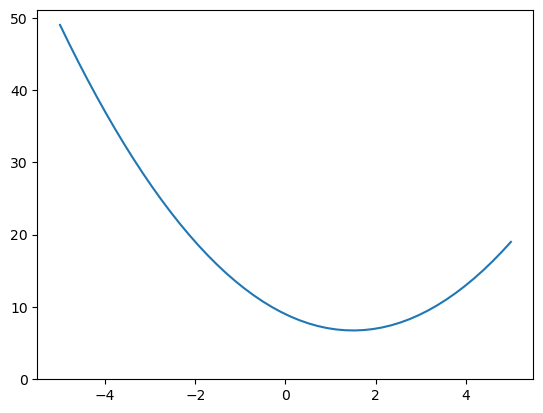

In [492]:
# DO NOT CHANGE

xs = np.linspace(-5, 5)
plt.plot(xs, xs * xs - 3 * xs + 9)
plt.ylim(0);

In [493]:
# YOUR CHANGES HERE
def calculate_p3(x):
    return ((2 * x) - 3)
p3 = calculate_p3(2)

Check the value of `p3`.

In [494]:
p3

1

### Problem 4

Set `p4` to the mean row of the mango data set.
That is, `p4` should be a single row of data with the same columns, where each value is the mean of the corresponding column in the mango data set.

In [495]:
# YOUR CHANGES HERE

p4 = mango_data.mean()

In [496]:
p4

green_rating           3.000
yellow_rating          3.000
softness               2.375
wrinkles               0.750
estimated_flavor       2.500
estimated_sweetness    2.250
rated_flavor           2.000
dtype: float64

### Problem 5

Set `p5` to be the median of the estimated flavor column in the mango data set.

You may find NumPy's [numpy.median](https://numpy.org/doc/stable/reference/generated/numpy.median.html) function or pandas' [pandas.DataFrame.median](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.median.html) method helpful.

In [497]:
# YOUR CHANGES HERE

p5 = np.median(mango_data["estimated_flavor"])

Check the value of `p5`.

In [498]:
p5

2.0

### Problem 6

How many local extrema does the function $x^3 - 3x$ have?

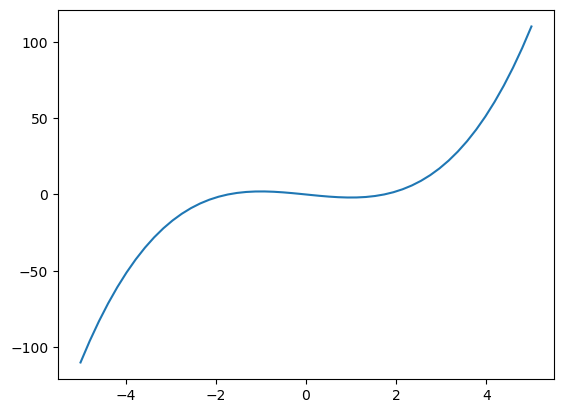

In [499]:
# @title Plot of $x^3 - 3x$

xs = np.linspace(-5,5)
plt.plot(xs, xs**3 - 3 * xs);

In [500]:
# YOUR CHANGES HERE
def f(x):
    # original funtion
    return ((x ** 3) - (3*x))


def f_prime(x):
    # First derivative
    return (3 * (x ** 2) - 3)


def f_double_prime(x):
    # Second derivative
    return 6*x

def solve_quadratic(a,b,c):
    # solve quadratic
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return []
    elif discriminant == 0:
        return [-b / (2*a)]
    else:
        sqrt_discriminant = math.sqrt(discriminant)
        x1 = (-b + sqrt_discriminant) / (2 * a)
        x2 = (-b - sqrt_discriminant) / (2 * a)
        return[x1, x2]

def find_critical_points():
    # Find critical points
    a=3
    b=0
    c=-3
    critical_points = solve_quadratic(a,b,c)
    return sorted(critical_points)

def count_local_extrema():
    critical_points = find_critical_points()
    extrema_count = 0
    for x in critical_points:
        first_deriv = f_prime(x)
        second_deriv = f_double_prime(x)
        func_value = f(x)
        if abs( first_deriv) < 1e-10:
            if second_deriv > 0:
                extrema_count += 1 #Local minima
            elif second_deriv < 0:
                extrema_count += 1 # Local maxima
            else:
               print(f"  → Inconclusive (f''(x) = 0)")
    return extrema_count 


p6 = count_local_extrema()

Check the value of `p6`.

In [501]:
p6

2

### Problem 7

Set `p7` to the number of following functions that are convex.

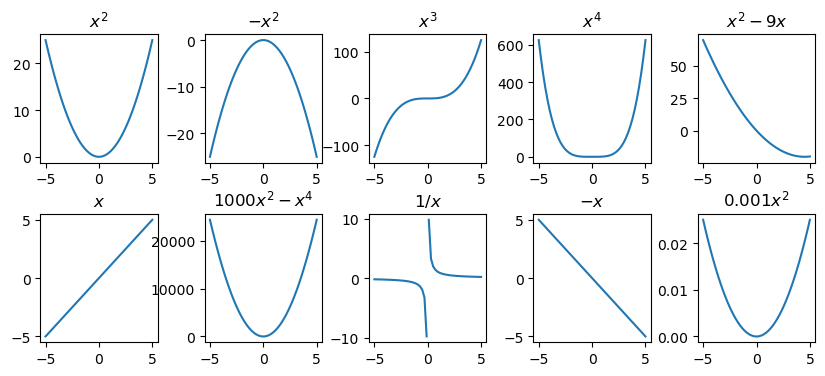

In [502]:
# @ title Functions to Check for Convexity

xs = np.linspace(-5, 5)

plt.figure(figsize=(10, 4))
plt.subplot(2, 5, 1)
plt.plot(xs, xs**2)
plt.title("$x^2$")

plt.subplot(2, 5, 2)
plt.plot(xs, -xs**2)
plt.title("$-x^2$")

plt.subplot(2, 5, 3)
plt.plot(xs, xs**3)
plt.title("$x^3$")

plt.subplot(2, 5, 4)
plt.plot(xs, xs**4)
plt.title("$x^4$")

plt.subplot(2, 5, 5)
plt.plot(xs, xs*xs - 9 * xs)
plt.title("$x^2 - 9x$")

plt.subplot(2, 5, 6)
plt.plot(xs, xs)
plt.title("$x$")

plt.subplot(2, 5, 7)
plt.plot(xs, -xs**4+1000 * xs**2)
plt.title("$1000x^2 - x^4$")

plt.subplot(2, 5, 8)
plt.plot([x for x in xs if x > 0], [1 / x for x in xs if x > 0], color="C0")
plt.plot([x for x in xs if x < 0], [1 / x for x in xs if x < 0], color="C0")
plt.title("$1/x$")

plt.subplot(2, 5, 9)
plt.plot(xs, -xs)
plt.title("$-x$")

plt.subplot(2, 5, 10)
plt.plot(xs, 0.001 * xs**2)
plt.title("$0.001 x^2$")

plt.subplots_adjust(hspace=0.4, wspace=0.4);

Hint: Convexity is a global property of functions.
You may want to change the range of x values to see the big picture.

In [503]:
# YOUR CHANGES HERE
def is_convex_simple(func, x_min=-50, x_max=50, num_points=1000):
    # Simple convexity check using numerical second derivative
    x = np.linspace(x_min, x_max, num_points)
    try:
        y = func(x)
        dx = x[1] - x[0]
        # Second derivative ≈ (f(x+h) - 2f(x) + f(x-h)) / h²
        second_derivative = (y[2:] - 2*y[1:-1] + y[:-2]) / (dx ** 2)
        return np.all(second_derivative >= -1e-10)
    except:
        return False
    
# Define all functions
def f1(x): return x**2
def f2(x): return -x**2  
def f3(x): return x**3
def f4(x): return x**4
def f5(x): return x**2 - 9*x
def f6(x): return x
def f7(x): return 1000*x**2 - x**4
def f8(x): return np.where(x != 0, 1/x, np.inf)  # Handle division by zero
def f9(x): return -x
def f10(x): return 0.001 * x**2

functions = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10]
names = ["x2", "-x2", "x3", "x4", "x2-9", "x", "1000x2-x4", "1/x", "-x", "0.001x2"]

convex_count = 0
for i, (func, name) in enumerate(zip(functions, names)):
    result = is_convex_simple(func)
    if result:
        convex_count += 1    

p7 = convex_count

Check the value of `p7`.

In [504]:
p7

6

### Problem 8

Set `p8` to $\lim_{x \to 2^-} \frac{|x-2|}{x-2}$.

In [505]:
# YOUR CHANGES HERE
def function_p8(x):
    return int(abs(x - 2)/ (x  - 2))

# take a value sligtly less than 2
p8 = function_p8(2 - 1e-10)

Check the value of `p8`.

In [506]:
p8

-1

### Problem 9

Write a function `p9` returning the derivative of $x^5$.

In [507]:
# YOUR CHANGES HERE

def p9(x):
    return 5 * (x ** 4)

Check the output of `p9`.

In [508]:
p9(0)

0

In [509]:
p9(1)

5

### Problem 10

Write a function `p10` returning the derivative of $4 x^2$.

In [510]:
# YOUR CHANGES HERE

def p10(x):
    return 8 * x

Check the output of `p10`.

In [511]:
p10(0)

0

In [512]:
p10(1)

8

### Problem 11

Write a function `p11` returning the derivative of $3 e^x + 5 x^5$.

In [513]:
# YOUR CHANGES HERE

def p11(x):
    e = math.e
    return 3 * math.exp(x) + 25 * (x ** 4)

Check the output of `p11`.

In [514]:
p11(0)

3.0

In [515]:
p11(1)

33.15484548537714

### Problem 12

Write a function `p12` returning the derivative of $\log_3(x)$.

You could try to derive this using the chain rule, but feel free to look up the rule for logarithms with different bases.

In [516]:
# YOUR CHANGES HERE

def p12(x):
    return 1 / (x * math.log(3))

Check the output of `p12`.

In [517]:
p12(1)

0.9102392266268373

In [518]:
p12(3)

0.30341307554227914

### Problem 13

Build a linear regression for the mango rated flavor column using all the other columns as inputs.
Set `p13` to be the output of this model for the mean row of the data set (similar to your answer to problem 4, but without the rated flavor column).

In [519]:
# YOUR CHANGES HERE
from sklearn.linear_model import LinearRegression
# Step 1 Features (exclude rated flavor column)
features = mango_data.drop(columns=["rated_flavor"])

# Step 2 fit the model
model = LinearRegression()
X_model = features
y_model = mango_data["rated_flavor"]
model.fit(X_model, y_model)

#Step 3: Predict on the mean
mean_row = features.mean().to_frame().T
p13 = model.predict(mean_row)[0]

Check the value of `p13`.

In [520]:
p13

2.0

### Problem 14

The derivative of the polynomial $5 x^{99} - 2 x^78 + 3 x^{25} + 4 x^4 -357$ is another polynomial.
What is the degree of that polynomial?

In [521]:
# YOUR CHANGES HERE
def derivative_degree(poly_str):
    # split the string by + and -
    import re
    terms = re.findall(r'[+-]?\s*[^+-]+', poly_str)
    max_deg = 0
    for term in terms:
        term = term.replace(' ', '')
        # skip constants
        if 'x' not in term:
            continue
        if '**' in term:
            parts = term.split('**')
            deg = int(parts[1])
        else:
            deg = 1
        # degree of derivative
        deriv_deg = deg - 1
        if deriv_deg > max_deg:
            max_deg = deriv_deg
            
    return max_deg

poly = "5*x**99 - 2*8*x**7 + 3*x**25 + 4*x**4 - 357"
p14 = derivative_degree(poly_str=poly)

Check the value of `p14`.

In [522]:
p14

98

### Problem 15

Write a function `p15` that takes in parameters `m` and `b` and computes the average $L_2$ loss for the training data in `x15` and `y15` based on the linear prediction $mx + b$.

In [523]:
# DO NOT CHANGE

x15 = np.asarray([0, 1, 2, 3, 4])
y15 = np.asarray([0, 0, 1, 1, 1])

In [524]:
# YOUR CHANGES HERE

def p15(m, b):
    # Linear prediction
    y_pred = m * x15 + b

    # L2 loss
    loss = (y15 - y_pred) ** 2

    # Average loss
    return np.mean(loss)

Test `p15` with different inputs.

In [525]:
p15(0, 0)

0.6

In [526]:
p15(0, 1)

0.4

In [527]:
p15(1, 0)

3.0

In [528]:
p15(1, 1)

6.8

### Problem 16

Write a function `p16` that takes in four parameters, `a`, `b`, `c`, and `x_in`, and returns the derivative of $ax^2 + bx +c$ evaluated at value $x=x_{in}$.

That is, `p16` should compute $\frac{d (ax^2 + bx +c)}{dx}(x_{in})$.

In [529]:
# YOUR CHANGES HERE

def p16(a, b, c, x_in):
    return 2 * a * x_in + b

### Problem 17

Set `p17` to $\lim_{x \to 0} x^2 \mathrm{cos} \left( \frac{1}{x} \right)$.

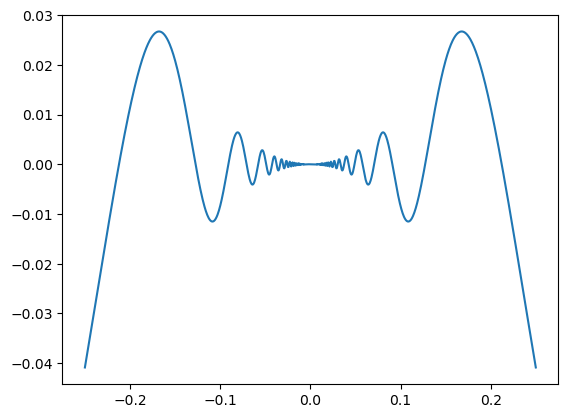

In [530]:
# @title Plot of $x^2 cos(1/x)

xs = np.linspace(-0.25, 0.25, 1000)
plt.plot(xs, xs**2 * np.cos(1 / xs));

Hint: This one looks tricky because $\mathrm{cos} \left( \frac{1}{x} \right)$ oscillates increasingly fast as $x$ approaches zero.
However, you should still be able to bound its behavior.

In [531]:
# YOUR CHANGES HERE
def function_p17(xs):
    return xs**2 * np.cos(1 / xs)

vals = function_p17(xs[1:])  # skip xs[0] = 0 to avoid division by zero
# print(vals[:10])             # see first 10 values
# print(vals.mean()) 
p17 = 0

In [532]:
p17

0

### Problem 18

Given a model with a single parameter $c$ whose loss function in terms of $c$ is convex, and given the following samples of the loss function output, what is the best (highest) lower bound that you can put on the optimal value of $c$?

| c | Loss(c) |
|---:|---:|
| 0 | 1.0 |
| 1 | 0.5 |
| 2 | 0.25 |
| 3 | 0.125 | 
| 4 | 0.25 |
| 5 | 0.6 |
| 6 | 0.9 |

In [533]:
# YOUR CHANGES HERE
def best_lower_bound(samples):
    """
    samples: list of (c, L(c)) pairs (c can be numeric)
    returns: best guaranteed lower bound on the minimizer c*
    """
    samples = sorted(samples, key=lambda x: x[0])
    bound = None
    for i in range(1, len(samples)):
        # if we observed a decrease from previous to current,
        # the minimizer must be to the right of previous c
        if samples[i][1] < samples[i-1][1]:
            bound = samples[i-1][0]   # record the previous c (not the current one)
        else:
            # once we hit the first non-decrease, we can stop
            break

    # if we never saw any decrease, return the leftmost c (minimizer could be at or left of it)
    return samples[0][0] if bound is None else bound

samples = [(0, 1.0), (1, 0.5), (2, 0.25), (3, 0.125), (4, 0.25), (5, 0.6), (6, 0.9)]
p18 = best_lower_bound(samples)

Check the value of `p18`.

In [534]:
p18

2

### Problem 19

Write a function `p19` that returns the strings "cat", "dog", "cow", "tiger" or "horse" with equal probability.

In [535]:
# YOUR CHANGES HERE

def p19():
    arr = ["cat", "dog", "cow", "tiger" , "horse"]
    return arr[random.randint(0,4)]

In [536]:
[p19() for _ in range(10)]

['cow', 'horse', 'dog', 'horse', 'dog', 'dog', 'cat', 'cow', 'tiger', 'horse']

### Problem 20

Set `p20` to the value of $x$ that minimizes $x^4 + 3x^3 + 2x + 5$.

In [537]:
def q20(x):
    return x**4 + 3 * x**3 + 2*x + 5

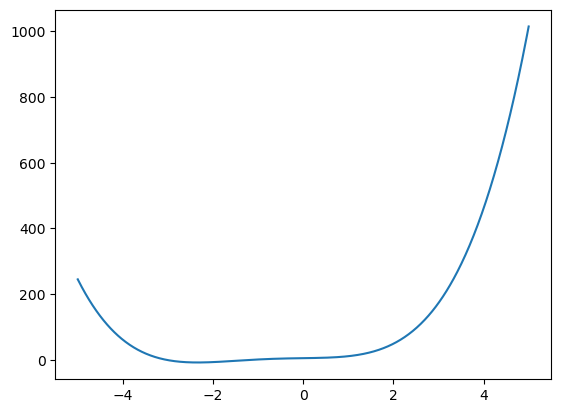

In [538]:
# @title Plot of $x^4 + 3x^3 + 2x + 5$

xs = np.linspace(-5, 5, 1000)
plt.plot(xs, xs**4 + 3 * xs**3 + 2*xs + 5);

Hint: whatever tactics you prefer to minimize this function numerically.

In [539]:
# YOUR CHANGES HERE
# Coefficients of derivative: 4x^3 + 9x^2 + 0*x + 2
coeffs = [4, 9, 0, 2]

# Find roots
roots = np.roots(coeffs)

# Only real roots are relevant
real_roots = [r.real for r in roots if np.isreal(r)]

p20 = min(real_roots, key=q20)

Check the value of `p20`.

In [540]:
p20

-2.3412191203287716

In [541]:
q20(p20)

-8.136534191343898

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

YOUR ANSWER HERE